#UCI Heart Disease (Cleveland)

**Heart disease Preprocessing Pipeline**

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight

In [3]:
columns = ["age","sex","cp","trestbps","chol","fbs","restecg",
           "thalach","exang","oldpeak","slope","ca","thal","target"]
df = pd.read_csv("processed.cleveland.data", names=columns)
print("Shape:", df.shape)

df.head()

Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [ ]:
df.dtypes

,0
age,float64
sex,float64
cp,float64
trestbps,float64
chol,float64
fbs,float64
restecg,float64
thalach,float64
exang,float64
oldpeak,float64


In [5]:
df.replace('?', np.nan, inplace=True)
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [6]:
df_clean = df.dropna().copy()
print("new shape:", df_clean.shape[0])

new shape: 297


Since binary classification so converting target column into a binary column<br>
heart disease present (1) vs absent (0)

In [7]:
df_clean["target"] = (df_clean["target"].astype(float) > 0).astype(int)

counts  = df_clean["target"].value_counts()
percent = df_clean["target"].value_counts(normalize=True) * 100
print(counts)
print(percent)

target
0    160
1    137
Name: count, dtype: int64
target
0    53.872054
1    46.127946
Name: proportion, dtype: float64


In [ ]:
counts = df_clean['target'].value_counts()
percent = df_clean['target'].value_counts(normalize=True) * 100

print("Counts:\n", counts)
print("\nPercentage:\n", percent)

Counts:
 target
0    160
1    137
Name: count, dtype: int64

Percentage:
 target
0    53.872054
1    46.127946
Name: proportion, dtype: float64


The dataset is relatively balanced, as both classes are nearly equally represented. There is no severe skew toward either class, which means the model is unlikely to be biased heavily toward one class during training.


---



Since the imbalance is minor, applying Synthetic Minority Over-sampling Technique (SMOTE) is not necessary, as it could artificially introduce synthetic samples and potentially distort the natural distribution of clinical data.

Instead, class weighting is more appropriate because:

It preserves the original dataset distribution
It avoids introducing synthetic data
It is computationally efficient
It is well-suited for small to moderate imbalance

In [8]:
X_raw = df_clean.drop("target", axis=1)
y     = df_clean["target"]

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_raw, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train_raw.shape, X_test_raw.shape)

(237, 13) (60, 13)


OHE

In [9]:
cat_cols = ["cp", "restecg", "slope", "thal"]
num_cols = ["age", "trestbps", "chol", "thalach", "oldpeak", "ca"]

X_train_enc = pd.get_dummies(X_train_raw, columns=cat_cols)
X_test_enc  = pd.get_dummies(X_test_raw,  columns=cat_cols)

X_train_enc, X_test_enc = X_train_enc.align(X_test_enc, join="left", axis=1, fill_value=0)

print("Train shape:", X_train_enc.shape, " Test shape:", X_test_enc.shape)

Train shape: (237, 22)  Test shape: (60, 22)


standard scaler

In [10]:
scaler = StandardScaler()

X_train_enc[num_cols] = scaler.fit_transform(X_train_enc[num_cols])
X_test_enc[num_cols]  = scaler.transform(X_test_enc[num_cols])

class weights

In [11]:
classes = np.unique(y_train)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y_train)
class_weight_dict = dict(zip(classes.tolist(), weights.tolist()))
print("Class weights:", class_weight_dict)

Class weights: {0: 0.92578125, 1: 1.0871559633027523}


corr matrix

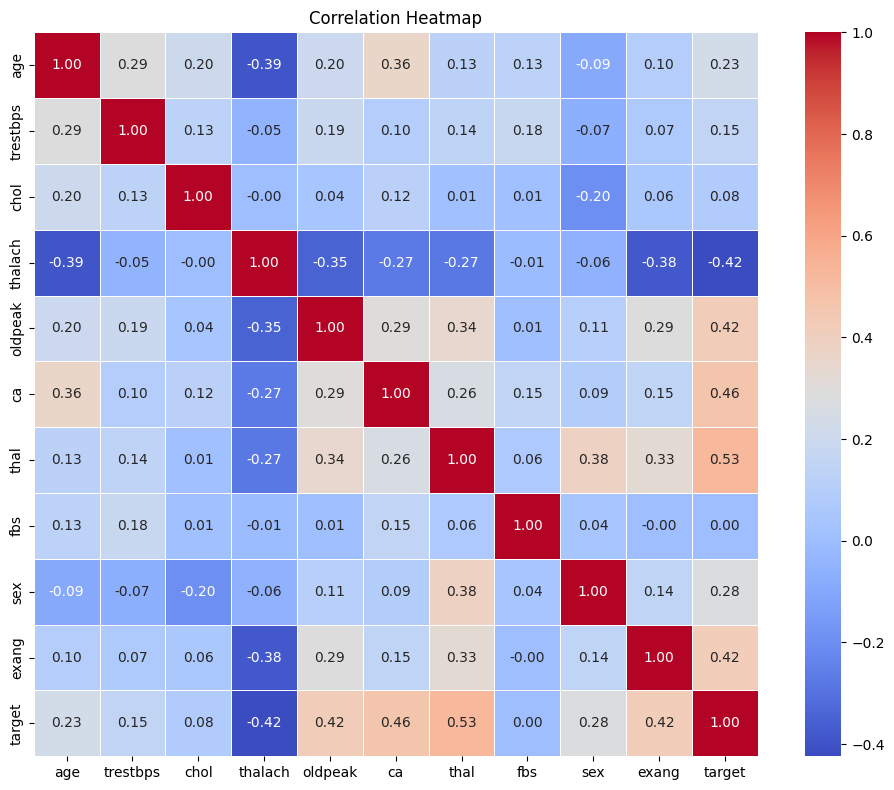


Top 3 strongest correlations:
thal     target    0.526640
ca       target    0.463189
oldpeak  target    0.424052
dtype: float64


In [12]:
numeric_features = ["age","trestbps","chol","thalach","oldpeak","ca","thal","fbs","sex","exang","target"]
corr = df_clean[numeric_features].astype(float).corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

corr_pairs = (corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
                  .stack().abs().sort_values(ascending=False))
print("\nTop 3 strongest correlations:")
print(corr_pairs.head(3))

In [13]:
joblib.dump(X_train_enc,       "X_train.pkl")
joblib.dump(X_test_enc,        "X_test.pkl")
joblib.dump(y_train,           "y_train.pkl")
joblib.dump(y_test,            "y_test.pkl")
joblib.dump(scaler,            "scaler.pkl")
joblib.dump(class_weight_dict, "class_weights.pkl")
joblib.dump(X_train_raw,       "X_train_raw.pkl")
joblib.dump(X_test_raw,        "X_test_raw.pkl")
joblib.dump(df_clean,          "df_clean.pkl")
joblib.dump(cat_cols,          "cat_cols.pkl")
joblib.dump(num_cols,          "num_cols.pkl")

print("saved.")

saved.
